<a href="https://colab.research.google.com/github/andrealopez47/goatdevice_evaluation/blob/main/temperature_graphs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

    Tref   Tdut  Error
0  36.40  36.22  -0.18
1  36.50  36.40  -0.10
2  36.60  36.50  -0.10
3  35.31  35.40   0.09
4  35.27  35.40   0.13


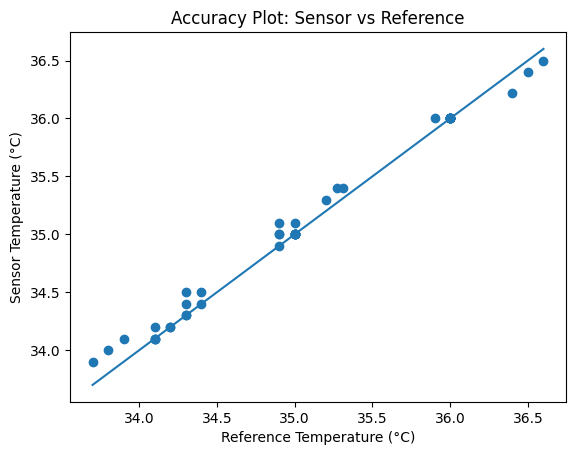

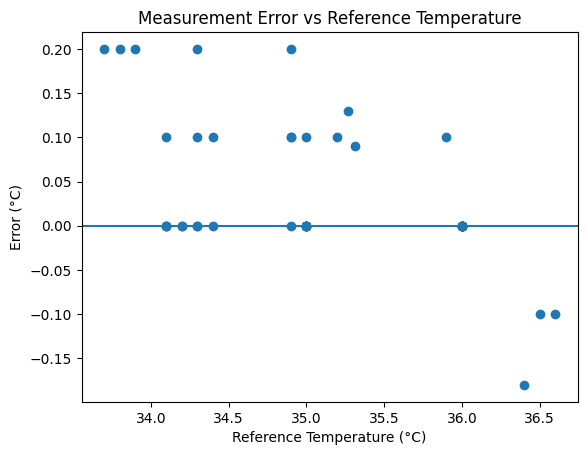

Mean Error: 0.036 °C
RMSE: 0.089 °C
Standard Deviation: 0.082 °C
SEM: 0.012 °C


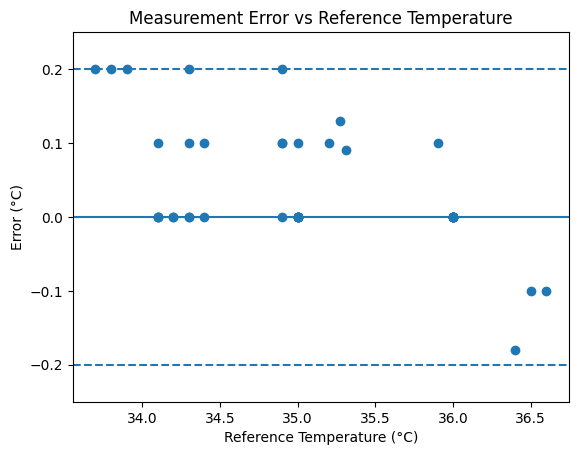

In [ ]:
# ==========================================
# IMPORT LIBRARIES
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


# ==========================================
# TEMPERATURE DATA
# ==========================================

data = {

    "Tref": [
        36.4, 36.5, 36.6,
        35.31, 35.27, 35.2,
        33.9, 33.8, 33.7,
        34.9, 34.9, 34.9,
        36, 36, 36,
        34.3, 34.3, 34.2,
        34.9, 35, 35,
        35.9, 36, 36,
        34.4, 34.3, 34.3,
        35, 35, 35,
        36, 36, 36,
        34.1, 34.1, 34.1,
        35, 35, 35,
        36, 36, 36,
        34.4, 34.2, 34.1
    ],

    "Tdut": [
        36.22, 36.4, 36.5,
        35.4, 35.4, 35.3,
        34.1, 34, 33.9,
        34.9, 35, 35.1,
        36, 36, 36,
        34.4, 34.3, 34.2,
        35, 35, 35,
        36, 36, 36,
        34.5, 34.5, 34.3,
        35, 35, 35.1,
        36, 36, 36,
        34.1, 34.1, 34.1,
        35, 35, 35,
        36, 36, 36,
        34.4, 34.2, 34.2
    ]
}


# ==========================================
# CREATE DATAFRAME
# ==========================================

df = pd.DataFrame(data)

# Calculate measurement error
df["Error"] = df["Tdut"] - df["Tref"]

# Display first rows
print(df.head())


# ==========================================
# ACCURACY PLOT
# ==========================================

plt.figure()

plt.scatter(df["Tref"], df["Tdut"])

# Ideal reference line
minv = min(df["Tref"])
maxv = max(df["Tref"])

plt.plot([minv, maxv], [minv, maxv])

plt.xlabel("Reference Temperature (°C)")
plt.ylabel("Sensor Temperature (°C)")
plt.title("Accuracy Plot: Sensor vs Reference")

plt.show()


# ==========================================
# ERROR PLOT
# ==========================================

plt.figure()

plt.scatter(df["Tref"], df["Error"])

# Zero-error reference line
plt.axhline(0)

plt.xlabel("Reference Temperature (°C)")
plt.ylabel("Error (°C)")
plt.title("Measurement Error vs Reference Temperature")

plt.show()


# ==========================================
# PERFORMANCE METRICS
# ==========================================

mean_error = df["Error"].mean()

rmse = np.sqrt(np.mean(df["Error"] ** 2))

std = df["Error"].std()

sem = std / np.sqrt(len(df["Error"]))

print("Mean Error:", round(mean_error, 3), "°C")
print("RMSE:", round(rmse, 3), "°C")
print("Standard Deviation:", round(std, 3), "°C")
print("SEM:", round(sem, 3), "°C")


# ==========================================
# ERROR LIMITS PLOT
# ==========================================

plt.figure()

plt.scatter(df["Tref"], df["Error"])

# Reference lines
plt.axhline(0)
plt.axhline(0.2, linestyle="--")
plt.axhline(-0.2, linestyle="--")

plt.xlabel("Reference Temperature (°C)")
plt.ylabel("Error (°C)")
plt.title("Measurement Error vs Reference Temperature")

plt.ylim(-0.25, 0.25)

plt.show()

Heating time 35.5 → 36.9: 09:38
Cooling time 35.5 → 34.0: 10:01
Temperature at ~5 min during heating: 36.3 °C at 04:44
Temperature at ~5 min during cooling: 34.2 °C at 05:31


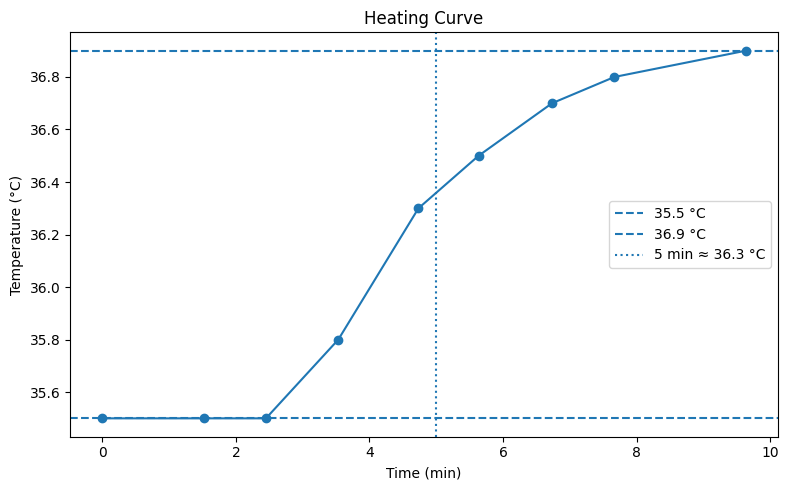

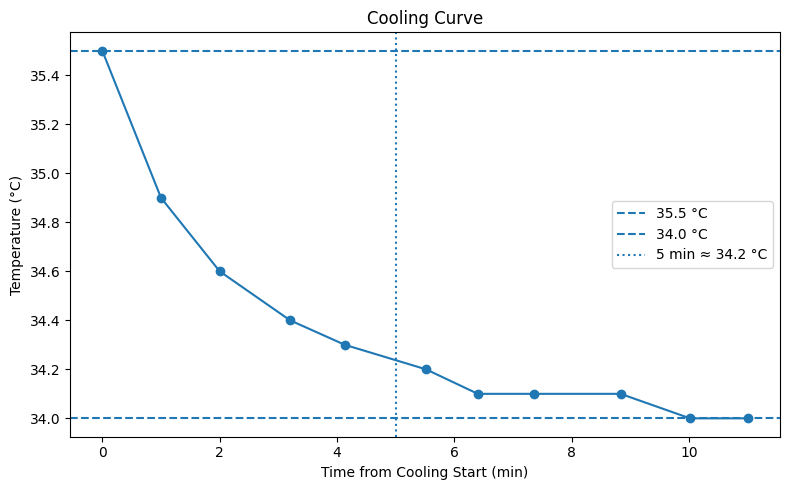

In [ ]:
# ==========================================
# IMPORT LIBRARIES
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt


# ==========================================
# TEMPERATURE DATA
# ==========================================

data = [
    [34.0, "18:54:54"],
    [34.0, "18:53:55"],
    [34.1, "18:52:44"],
    [34.1, "18:51:15"],
    [34.1, "18:50:18"],
    [34.2, "18:49:25"],
    [34.3, "18:48:02"],
    [34.4, "18:47:06"],
    [34.6, "18:45:54"],
    [34.9, "18:44:54"],
    [35.5, "18:43:54"],
    [35.6, "18:43:04"],
    [35.6, "18:42:07"],
    [35.6, "18:41:13"],
    [35.7, "18:40:19"],
    [35.8, "18:39:18"],
    [35.9, "18:38:21"],
    [36.0, "18:37:28"],
    [36.3, "18:36:32"],
    [36.8, "18:35:34"],
    [36.9, "18:34:34"],
    [36.9, "18:33:37"],
    [36.9, "18:32:36"],
    [36.8, "18:30:38"],
    [36.7, "18:29:42"],
    [36.5, "18:28:36"],
    [36.3, "18:27:42"],
    [35.8, "18:26:30"],
    [35.5, "18:25:25"],
    [35.5, "18:24:29"],
    [35.5, "18:22:58"],
]


# ==========================================
# CREATE DATAFRAME
# ==========================================

df = pd.DataFrame(data, columns=["temp", "timestamp"])

# Convert timestamp to datetime
df["timestamp"] = pd.to_datetime(df["timestamp"], format="%H:%M:%S")

# Sort by time
df = df.sort_values("timestamp").reset_index(drop=True)


# ==========================================
# TIME CALCULATION
# ==========================================

# Global time from first point
t0 = df.loc[0, "timestamp"]

df["time_s"] = (df["timestamp"] - t0).dt.total_seconds()

df["time_min"] = df["time_s"] / 60


# ==========================================
# TIME FORMAT FUNCTION
# ==========================================

def sec_to_mmss(seconds):

    m = int(seconds // 60)

    s = int(seconds % 60)

    return f"{m:02d}:{s:02d}"


# ==========================================
# HEATING ANALYSIS
# ==========================================

t_35_5_heat = df.loc[df["temp"] >= 35.5, "time_s"].iloc[0]

t_36_9_heat = df.loc[df["temp"] >= 36.9, "time_s"].iloc[0]

heating_time = t_36_9_heat - t_35_5_heat

df_heat = df[df["time_s"] <= t_36_9_heat].copy()

# Temperature at approximately 5 minutes
target_5min_s = 5 * 60

idx_heat_5 = (df_heat["time_s"] - target_5min_s).abs().idxmin()

temp_heat_5 = df_heat.loc[idx_heat_5, "temp"]

time_heat_5 = df_heat.loc[idx_heat_5, "time_s"]


# ==========================================
# COOLING ANALYSIS
# ==========================================

idx_35_5_cool = df[df["temp"] == 35.5].index[-1]

t_35_5_cool = df.loc[idx_35_5_cool, "time_s"]

df_cool = df[df["time_s"] >= t_35_5_cool].copy()

df_cool["time_s_rel"] = df_cool["time_s"] - t_35_5_cool

df_cool["time_min_rel"] = df_cool["time_s_rel"] / 60

idx_34 = df_cool[df_cool["temp"] <= 34.0].index[0]

t_34_rel = df_cool.loc[idx_34, "time_s_rel"]

cooling_time = t_34_rel

# Temperature at approximately 5 minutes
idx_cool_5 = (df_cool["time_s_rel"] - target_5min_s).abs().idxmin()

temp_cool_5 = df_cool.loc[idx_cool_5, "temp"]

time_cool_5 = df_cool.loc[idx_cool_5, "time_s_rel"]


# ==========================================
# RESULTS
# ==========================================

print("Heating time 35.5 → 36.9:", sec_to_mmss(heating_time))

print("Cooling time 35.5 → 34.0:", sec_to_mmss(cooling_time))

print(
    "Temperature at ~5 min during heating:",
    temp_heat_5,
    "°C at",
    sec_to_mmss(time_heat_5)
)

print(
    "Temperature at ~5 min during cooling:",
    temp_cool_5,
    "°C at",
    sec_to_mmss(time_cool_5)
)


# ==========================================
# HEATING CURVE
# ==========================================

plt.figure(figsize=(8, 5))

plt.plot(df_heat["time_min"], df_heat["temp"], marker="o")

plt.axhline(35.5, linestyle="--", label="35.5 °C")

plt.axhline(36.9, linestyle="--", label="36.9 °C")

plt.axvline(5, linestyle=":", label=f"5 min ≈ {temp_heat_5} °C")

plt.xlabel("Time (min)")

plt.ylabel("Temperature (°C)")

plt.title("Heating Curve")

plt.legend()

plt.tight_layout()

plt.show()


# ==========================================
# COOLING CURVE
# ==========================================

plt.figure(figsize=(8, 5))

plt.plot(df_cool["time_min_rel"], df_cool["temp"], marker="o")

plt.axhline(35.5, linestyle="--", label="35.5 °C")

plt.axhline(34.0, linestyle="--", label="34.0 °C")

plt.axvline(5, linestyle=":", label=f"5 min ≈ {temp_cool_5} °C")

plt.xlabel("Time from Cooling Start (min)")

plt.ylabel("Temperature (°C)")

plt.title("Cooling Curve")

plt.legend()

plt.tight_layout()

plt.show()